In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Archivo CSV limpio con columnas:
# polarizacion, V_d_V, I_d_A, T_K
CSV_FILE = "/home/jorge/Escritorio/Lab/Pr1/datos_diodo.csv"

data = np.genfromtxt(CSV_FILE, delimiter=",", names=True, dtype=None, encoding="utf-8")

V = data["V_d_V"].astype(float)
I = data["I_d_A"].astype(float)  # corriente medida en mA
T = float(np.mean(data["T_K"].astype(float)))

def shockley_ideal(V, Is, q_over_kB, n=1):
    x = q_over_kB * V / (n*T)
    return Is * np.expm1(x)

sigma = np.maximum(np.abs(I), 1e-9)

p0 = [1e-6, 1.1604e4]  # Is en mA, q/kB en K/V
bounds = ([0.0, 0.0], [np.inf, np.inf])

popt, pcov = curve_fit(
    shockley_ideal,
    V,
    I,
    p0=p0,
    bounds=bounds,
    sigma=sigma,
    absolute_sigma=False,
    maxfev=100000,
)

Is_fit, q_over_kB_fit = popt
perr = np.sqrt(np.diag(pcov))




In [25]:
print(f"T = {T:.2f} K = 24 C")
print(f"Is = {Is_fit*1000:.6e} μA ± {perr[0]*1000:.2e} μA")
print(f"q/kB = {q_over_kB_fit:.6e} K/V ± {perr[1]:.2e} K/V")
print(f"q/kB (exacto) =1.16045e4 K/V")



T = 297.15 K = 24 C
Is = 3.490862e-07 μA ± 3.04e-07 μA
q/kB = 7.315180e+03 K/V ± 3.82e+02 K/V
q/kB (exacto) =1.16045e4 K/V


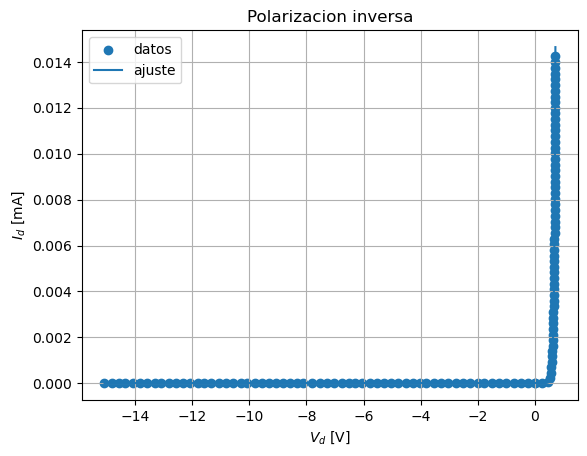

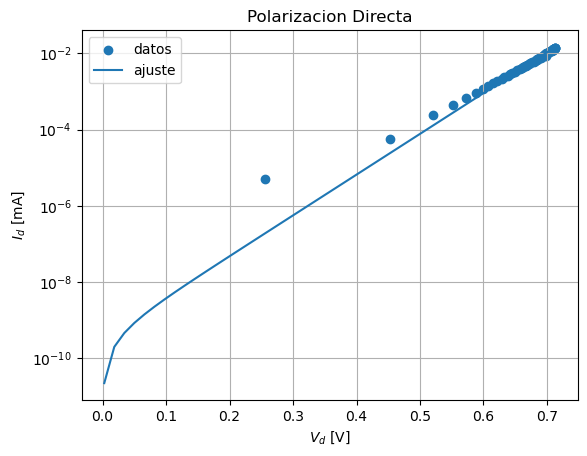

In [22]:
V_plot = np.linspace(V.min(), V.max(), 1000)
I_plot = shockley_ideal(V_plot, *popt)

plt.figure()
plt.scatter(V, I, label="datos")
plt.plot(V_plot, I_plot, label="ajuste")
plt.xlabel(r"$V_d$ [V]")
plt.ylabel(r"$I_d$ [mA]")
plt.title("Polarizacion inversa")
plt.legend()
plt.grid(True)
plt.show()

# Gráfica semilogarítmica rama directa.
mask_directa = I > 0
plt.figure()
plt.scatter(V[mask_directa], I[mask_directa], label="datos")
plt.plot(V_plot[V_plot > 0], I_plot[V_plot > 0], label="ajuste")
plt.yscale("log")
plt.xlabel(r"$V_d$ [V]")
plt.ylabel(r"$I_d$ [mA]")
plt.title("Polarizacion Directa")
plt.legend()
plt.grid(True, which="both")
plt.show()